#Celda — Paso 4.1: Cargar diccionario y datos de la Bienal

In [1]:
import pandas as pd

RUTA_BIENAL = "../../outputs/dataset_encuestaBienal_limpio.csv"
RUTA_DICC_BIENAL = "../../outputs/diccionario_preguntas_variables.csv"  # ajustar ruta si vive en otra carpeta

df_bienal = pd.read_csv(RUTA_BIENAL, encoding="utf-8-sig", low_memory=False)
dicc_bienal = pd.read_csv(RUTA_DICC_BIENAL, encoding="utf-8-sig", low_memory=False)

print(f"df_bienal: {df_bienal.shape}")
print(f"dicc_bienal: {dicc_bienal.shape}, columnas: {dicc_bienal.columns.tolist()}")

ITEMS_P10 = [f"P10.{i}" for i in range(1, 12)]   # P10.1 .. P10.11
ITEMS_P12 = [f"P12.{i}" for i in range(1, 7)]    # P12.1 .. P12.6
ITEMS_TOTAL = ITEMS_P10 + ITEMS_P12

print(f"\nTotal de ítems a verificar: {len(ITEMS_TOTAL)}")

# Verificar que las 17 columnas existen en df_bienal
faltantes = [c for c in ITEMS_TOTAL if c not in df_bienal.columns]
if faltantes:
    print(f"⚠️ Ítems no encontrados como columnas en df_bienal: {faltantes}")
    print("Revisar si el nombre de columna en el CSV usa otro formato (ej. 'P10_1' en vez de 'P10.1')")

# Imprimir el enunciado exacto de cada ítem desde el diccionario oficial
print("\n" + "="*90)
print("ENUNCIADO LITERAL DE CADA ÍTEM (verificar dirección uno por uno contra este texto)")
print("="*90)

for item in ITEMS_TOTAL:
    fila = dicc_bienal.loc[dicc_bienal["variable"] == item] if "variable" in dicc_bienal.columns else pd.DataFrame()
    if fila.empty:
        # Intentar con pregunta_codigo si 'variable' no es la columna de match
        col_match = "pregunta_codigo" if "pregunta_codigo" in dicc_bienal.columns else dicc_bienal.columns[0]
        fila = dicc_bienal.loc[dicc_bienal[col_match] == item]
    if fila.empty:
        print(f"\n{item}:NO ENCONTRADO en el diccionario — revisar nombre de columna de match")
        continue
    enunciado = fila["enunciado_subvariable"].iloc[0] if "enunciado_subvariable" in fila.columns else fila.iloc[0].to_dict()
    print(f"\n{item}: {enunciado}")

    # Mostrar también las opciones de respuesta observadas en los datos, si son pocas categorías
    if item in df_bienal.columns:
        print(f"    Valores únicos en datos: {sorted(df_bienal[item].dropna().unique())}")

df_bienal: (5860, 183)
dicc_bienal: (96, 12), columnas: ['variable', 'pregunta_codigo', 'pregunta_nombre', 'enunciado_pregunta', 'numero_seccion', 'seccion', 'tipo_variable', 'titulo_variable', 'enunciado_subvariable', 'etiqueta_corta', 'en_cubo', 'unidad_medida']

Total de ítems a verificar: 17

ENUNCIADO LITERAL DE CADA ÍTEM (verificar dirección uno por uno contra este texto)

P10.1: Las mujeres por naturaleza cuidan mejor a los(as) niños(as) que los hombres
    Valores únicos en datos: [np.int64(1), np.int64(2)]

P10.2: Las mujeres por naturaleza hacen mejor los oficios del hogar que los hombres
    Valores únicos en datos: [np.int64(1), np.int64(2)]

P10.3: Toda familia necesita un hombre que la proteja
    Valores únicos en datos: [np.int64(1), np.int64(2)]

P10.4: El rol de todo hombre es el de proteger y proveer a su familia
    Valores únicos en datos: [np.int64(1), np.int64(2)]

P10.5: La mujer es la principal responsable de prevenir un embarazo
    Valores únicos en datos: [n

In [2]:
# Confirmado: para TODOS los ítems P10.x y P12.x, 1 = "En desacuerdo", 2 = "De acuerdo"
# (fuente: Eriquetas_respuestas_consolidados.csv, indice_pregunta 36 y 38)

CODIFICACION_P10_P12 = {1: "En desacuerdo", 2: "De acuerdo"}

print("Codificación confirmada para los 17 ítems (P10.x, P12.x):")
print(CODIFICACION_P10_P12)

# Para el análisis factorial, conviene recodificar a una dirección semántica consistente:
# "acuerdo con la afirmación machista/de no-injerencia" = valor alto (2), que ya es la
# codificación nativa (2=De acuerdo). Esto significa que NO hace falta invertir nada:
# valores altos (2) ya significan "más acuerdo con la actitud problemática" en los 17 ítems,
# de forma uniforme. La correlación cruda del paso anterior ES interpretable directamente.

# Verificación de que esto es consistente con los pares de anclaje ya calculados:
# P10.1 vs P10.2, P10.3 vs P10.4, P10.9 vs P12.5, P12.1 vs P12.2
# Si ambos ítems de cada par usan la misma clave (1=desacuerdo, 2=acuerdo), la correlación
# cruda ya calculada en el paso anterior es válida tal cual, sin necesidad de invertir ítems.

print("\nComo los 17 ítems comparten exactamente la misma clave (1=En desacuerdo, "
      "2=De acuerdo), NO se requiere invertir ningún ítem antes del análisis factorial. "
      "La dirección ya es uniforme: valores altos = mayor acuerdo con la afirmación "
      "(sea esencialista, de control, o de no-injerencia).")

Codificación confirmada para los 17 ítems (P10.x, P12.x):
{1: 'En desacuerdo', 2: 'De acuerdo'}

Como los 17 ítems comparten exactamente la misma clave (1=En desacuerdo, 2=De acuerdo), NO se requiere invertir ningún ítem antes del análisis factorial. La dirección ya es uniforme: valores altos = mayor acuerdo con la afirmación (sea esencialista, de control, o de no-injerencia).


#Celda — Paso 4.2: KMO y test de esfericidad de Bartlett

In [3]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Base analítica: los 17 ítems, listwise deletion (factor_analyzer no admite NaN)
df_items = df_bienal[ITEMS_TOTAL].dropna()

n_original = len(df_bienal)
n_analitico = len(df_items)
print(f"n original: {n_original}")
print(f"n analítico (listwise, 17 ítems completos): {n_analitico} "
      f"({n_analitico/n_original*100:.1f}%)")

# --- KMO ---
kmo_por_item, kmo_total = calculate_kmo(df_items)

print(f"\nKMO global (Kaiser-Meyer-Olkin): {kmo_total:.4f}")
print(f"Umbral requerido: > 0,60")
print(f"{'Cumple' if kmo_total > 0.60 else '⚠️ NO cumple'}")

print("\nKMO por ítem (MSA individual):")
kmo_items_df = pd.DataFrame({"item": ITEMS_TOTAL, "kmo_msa": kmo_por_item}).sort_values("kmo_msa")
print(kmo_items_df.to_string(index=False))

items_kmo_bajo = kmo_items_df.loc[kmo_items_df["kmo_msa"] < 0.50, "item"].tolist()
if items_kmo_bajo:
    print(f"\nÍtems con MSA individual < 0,50 (candidatos a excluir si se factoriza): {items_kmo_bajo}")

# --- Test de esfericidad de Bartlett ---
chi_cuadrado, p_valor_bartlett = calculate_bartlett_sphericity(df_items)

print(f"\nTest de esfericidad de Bartlett:")
print(f"  Chi-cuadrado: {chi_cuadrado:.2f}")
print(f"  p-valor: {p_valor_bartlett:.6f}")
print(f"  Umbral requerido: p < 0,05")
print(f"  {'Cumple' if p_valor_bartlett < 0.05 else '⚠️ NO cumple'}")

# --- Decisión ---
cumple_kmo = kmo_total > 0.60
cumple_bartlett = p_valor_bartlett < 0.05

print("\n" + "="*60)
if cumple_kmo and cumple_bartlett:
    print("AMBOS criterios cumplidos — se procede a factorizar (Paso 4.3).")
else:
    print("NO se cumplen ambos criterios — NO factorizar.")
    print("   Se reportan los 17 ítems individualmente, sin reducción factorial.")

n original: 5860
n analítico (listwise, 17 ítems completos): 5860 (100.0%)

KMO global (Kaiser-Meyer-Olkin): 0.9045
Umbral requerido: > 0,60
Cumple

KMO por ítem (MSA individual):
  item  kmo_msa
 P10.1 0.756742
 P10.2 0.829577
 P12.1 0.894385
 P12.3 0.900878
 P10.3 0.902779
 P12.5 0.904379
 P10.4 0.904740
 P12.2 0.905955
 P12.4 0.909137
 P12.6 0.911589
 P10.8 0.914184
 P10.9 0.916009
P10.11 0.926382
 P10.7 0.926816
 P10.6 0.931521
P10.10 0.934560
 P10.5 0.944364

Test de esfericidad de Bartlett:
  Chi-cuadrado: 32136.48
  p-valor: 0.000000
  Umbral requerido: p < 0,05
  Cumple

AMBOS criterios cumplidos — se procede a factorizar (Paso 4.3).


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [4]:
import numpy as np

# --- 1. Diagnóstico de la matriz de correlación Pearson (phi, sobre binarios) ---
corr_matrix = df_items.corr()
det_corr = np.linalg.det(corr_matrix)
eigenvalues = np.linalg.eigvalsh(corr_matrix)

print(f"Determinante de la matriz de correlación (Pearson/phi): {det_corr:.2e}")
print(f"Autovalores (ordenados de menor a mayor):")
print(np.sort(eigenvalues))
print(f"\nAutovalores negativos: {(eigenvalues < 0).sum()}")
print(f"Autovalores muy cercanos a 0 (<0.01): {(eigenvalues < 0.01).sum()}")

# --- 2. Condición de la matriz (razón autovalor máximo / mínimo) ---
cond_number = eigenvalues.max() / eigenvalues[eigenvalues > 1e-10].min() if (eigenvalues > 1e-10).any() else np.inf
print(f"\nNúmero de condición: {cond_number:.1f}")
print("(valores muy altos, >1000, indican multicolinealidad severa entre ítems)")

# --- 3. Comparar correlación Pearson (phi) vs. tetracórica en un subconjunto de pares ---
# La tetracórica asume una variable latente continua normal detrás de cada binaria;
# Pearson/phi sobre binarios SIEMPRE subestima la correlación tetracórica cuando los
# splits (proporciones de 1 vs 2) no son ambos 50/50 -- lo cual es justo nuestro caso
# (ver proporciones ya calculadas antes: varían bastante entre ítems).

try:
    from semopy import polycorr  # opción 1 si está disponible
    tiene_semopy = True
except ImportError:
    tiene_semopy = False

try:
    import polychoric  # opción 2
    tiene_polychoric = True
except ImportError:
    tiene_polychoric = False

print(f"\nLibrerías para correlación tetracórica disponibles: "
      f"semopy={tiene_semopy}, polychoric={tiene_polychoric}")

# --- 4. Verificación indirecta: proporciones de cada ítem (splits) ---
# Si los splits están lejos de 50/50, la subestimación de Pearson/phi respecto a
# tetracórica es mayor -- esto es lo que decide si vale la pena el esfuerzo de recalcular
print("\nProporción de 'De acuerdo' (código 2) por ítem — splits alejados de 50% sugieren "
      "mayor subestimación de Pearson/phi respecto a tetracórica:")
splits = df_items.apply(lambda col: (col == 2).mean()).sort_values()
print(splits.round(3))

splits_extremos = splits[(splits < 0.20) | (splits > 0.80)]
print(f"\nÍtems con split extremo (<20% o >80% de acuerdo): {len(splits_extremos)} de {len(ITEMS_TOTAL)}")
print(splits_extremos.round(3))

Determinante de la matriz de correlación (Pearson/phi): 4.12e-03
Autovalores (ordenados de menor a mayor):
[0.39955939 0.42412989 0.42900414 0.44771024 0.47293372 0.51059279
 0.5267903  0.53680273 0.59055474 0.61275889 0.63242794 0.75635554
 0.83933032 0.99284933 1.11790578 2.02287716 5.6874171 ]

Autovalores negativos: 0
Autovalores muy cercanos a 0 (<0.01): 0

Número de condición: 14.2
(valores muy altos, >1000, indican multicolinealidad severa entre ítems)

Librerías para correlación tetracórica disponibles: semopy=False, polychoric=False

Proporción de 'De acuerdo' (código 2) por ítem — splits alejados de 50% sugieren mayor subestimación de Pearson/phi respecto a tetracórica:
P10.10    0.306
P10.6     0.311
P10.7     0.319
P12.3     0.322
P10.5     0.344
P12.2     0.361
P12.1     0.389
P12.5     0.391
P10.9     0.406
P12.6     0.415
P10.8     0.438
P10.11    0.438
P12.4     0.465
P10.2     0.488
P10.3     0.509
P10.1     0.512
P10.4     0.557
dtype: float64

Ítems con split extremo

In [5]:
texto_supuesto_4_2b = f"""
## Paso 4.2b — Verificación: Pearson vs. tetracórica para el análisis factorial (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

El cálculo de KMO/Bartlett (Paso 4.2) generó un warning de `factor_analyzer` sobre el
determinante de la matriz de correlación estar "cerca de cero", resuelto internamente
con pseudoinversa de Moore-Penrose. Se verificó si esto reflejaba multicolinealidad
genuina que ameritara recalcular con correlación tetracórica (más apropiada que Pearson
para ítems binarios) en vez de proceder con Pearson estándar.

**Resultado de la verificación:**
- Determinante: 4,12e-03 — pequeño pero explicado por 17 autovalores <1 multiplicados
  entre sí, no por un autovalor cercano a cero.
- **Autovalores:** todos positivos, mínimo 0,3996 — sin ningún valor cercano a 0.
- **Número de condición:** 14,2 — muy por debajo del umbral de multicolinealidad severa
  (>1000), matriz bien condicionada.
- **Splits de los 17 ítems** (proporción "De acuerdo"): rango 30,6%–55,7% — ningún ítem
  con split extremo (<20% o >80%), el escenario donde Pearson/phi más se aleja de la
  tetracórica.

**Decisión:** se mantiene la matriz de correlación de Pearson para la extracción
factorial (Paso 4.3). El warning de la librería fue un umbral numérico conservador sin
consecuencia sustantiva — no se instala infraestructura adicional (`semopy` u otra) para
recalcular con tetracórica, dado que la evidencia (autovalores, condición, splits) no
justifica el esfuerzo: la ganancia esperada de precisión sería marginal.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_4_2b)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 4.3: Alfa de Cronbach del conjunto completo (17 ítems)

In [6]:
import pingouin as pg

alfa_resultado = pg.cronbach_alpha(data=df_items)

alfa_valor, alfa_ic = alfa_resultado

print(f"Alfa de Cronbach (17 ítems, n={len(df_items)}): {alfa_valor:.4f}")
print(f"IC 95%: [{alfa_ic[0]:.4f}, {alfa_ic[1]:.4f}]")

# Comparación contra el rango esperado por el enunciado
RANGO_ESPERADO = (0.6, 0.7)
print(f"\nRango esperado según el enunciado: {RANGO_ESPERADO}")

if RANGO_ESPERADO[0] <= alfa_valor <= RANGO_ESPERADO[1]:
    print("Alfa dentro del rango esperado — consistente con la hipótesis de que "
          "'el machismo' no es una dimensión única (H-B).")
elif alfa_valor < RANGO_ESPERADO[0]:
    print("Alfa por DEBAJO del rango esperado — el conjunto es aún menos unidimensional "
          "de lo anticipado, refuerza aún más la hipótesis multidimensional.")
else:
    print("Alfa por ENCIMA del rango esperado — más consistencia interna de la anticipada; "
          "esto acercaría el resultado al escenario de refutación de H-B (Sección 1.4, "
          "escenario 3: 'un solo factor con alfa alto').")

# Alfa por bloque (P10 vs P12), para contexto adicional -- no reemplaza el análisis
# factorial del Paso 4.4/4.5, pero da una primera pista de si los dos bloques temáticos
# ya declarados en el diccionario (roles/P10 vs. control-pareja/P12) tienen consistencia
# interna distinta entre sí
alfa_p10, ic_p10 = pg.cronbach_alpha(data=df_items[ITEMS_P10])
alfa_p12, ic_p12 = pg.cronbach_alpha(data=df_items[ITEMS_P12])

print(f"\nAlfa solo P10 (11 ítems, roles/esencialismo): {alfa_p10:.4f}  IC95%: [{ic_p10[0]:.4f}, {ic_p10[1]:.4f}]")
print(f"Alfa solo P12 (6 ítems, control en la pareja): {alfa_p12:.4f}  IC95%: [{ic_p12[0]:.4f}, {ic_p12[1]:.4f}]")

Alfa de Cronbach (17 ítems, n=5860): 0.8731
IC 95%: [0.8680, 0.8780]

Rango esperado según el enunciado: (0.6, 0.7)
Alfa por ENCIMA del rango esperado — más consistencia interna de la anticipada; esto acercaría el resultado al escenario de refutación de H-B (Sección 1.4, escenario 3: 'un solo factor con alfa alto').

Alfa solo P10 (11 ítems, roles/esencialismo): 0.8483  IC95%: [0.8420, 0.8540]
Alfa solo P12 (6 ítems, control en la pareja): 0.8005  IC95%: [0.7920, 0.8080]


In [7]:
texto_supuesto_4_3 = f"""
## Paso 4.3 — Confiabilidad: Alfa de Cronbach, 17 ítems (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Alfa de Cronbach (17 ítems, n=5.860): 0,8731** (IC 95% [0,8680, 0,8780]).

**Resultado por encima del rango esperado en el enunciado (0,6–0,7).** El enunciado
anticipaba un alfa bajo-moderado como evidencia de que "el machismo" no es una dimensión
única. El resultado observado (0,87) es "bueno" a "muy bueno" según los estándares
convencionales de confiabilidad — sustancialmente más alto de lo previsto.

**Alfa por bloque temático (declarado en el diccionario de la Bienal):**
- P10 (roles tradicionales/esencialismo, 11 ítems): α = 0,8483 (IC95% [0,8420, 0,8540])
- P12 (control en la pareja, 6 ítems): α = 0,8005 (IC95% [0,7920, 0,8080])

Ambos subbloques tienen consistencia interna alta **por separado**, y el conjunto
completo de 17 ítems tiene consistencia aún más alta que cualquiera de los dos
subbloques individualmente — esto es consistente con la posibilidad de que exista un
factor general fuerte que atraviesa ambos bloques, además de (o en lugar de) la
distinción fina entre "roles tradicionales" y "no-injerencia/privatización" que H-B
proponía como la distinción sustantiva.

**Precaución metodológica — el alfa alto NO es, por sí solo, la prueba de refutación de
H-B.** El escenario de refutación preregistrado (Sección 1.4, escenario 3) especifica
dos condiciones conjuntas: *"si el análisis factorial arroja un solo factor con alfa de
Cronbach alto"*. Hasta este punto solo se ha verificado la segunda condición (alfa alto);
la primera (número de factores que emergen del análisis factorial exploratorio) se
determina en el Paso 4.4/4.5, aún pendiente. Un alfa alto es compatible con:
(a) un único factor dominante (lo cual sí refutaría H-B según el criterio preregistrado), o
(b) varios factores correlacionados entre sí que comparten un factor general de segundo
orden (patrón común en escalas de actitudes de género, y compatible con que H-B se
sostenga si esos factores específicos —roles vs. no-injerencia— emergen distinguibles
en la estructura factorial, aun con un alfa global alto).

**No se declara refutada H-B en este paso.** Se procede al Paso 4.4 (extracción y número
de factores) antes de emitir cualquier conclusión sobre el escenario de refutación.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_4_3)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 4.4: Determinación del número de factores

In [8]:
import sklearn.utils.validation as skv

# Parche de compatibilidad: factor_analyzer llama a check_array con el nombre viejo
# del parámetro (force_all_finite), que sklearn nuevo renombró a ensure_all_finite.
_check_array_original = skv.check_array

def _check_array_parcheado(*args, **kwargs):
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _check_array_original(*args, **kwargs)

skv.check_array = _check_array_parcheado

# El módulo factor_analyzer ya importó check_array en su propio namespace al cargarse,
# así que también hay que parchear la referencia que él mismo usa:
import factor_analyzer.factor_analyzer as fa_module
fa_module.check_array = _check_array_parcheado

print("Parche de compatibilidad aplicado — check_array ahora acepta force_all_finite")

Parche de compatibilidad aplicado — check_array ahora acepta force_all_finite


In [9]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

# --- (a) Autovalores > 1 (criterio de Kaiser) ---
fa_sin_rotar = FactorAnalyzer(rotation=None, n_factors=len(ITEMS_TOTAL))
fa_sin_rotar.fit(df_items)
autovalores, _ = fa_sin_rotar.get_eigenvalues()

n_factores_kaiser = (autovalores > 1).sum()
print(f"Autovalores: {np.round(autovalores, 3)}")
print(f"\n(a) Criterio de Kaiser (autovalores > 1): sugiere {n_factores_kaiser} factores")


# --- (c) Análisis paralelo de Horn ---
def analisis_paralelo_horn(datos, n_iter=100, percentil=95, seed=2026):
    """
    Análisis paralelo de Horn: genera n_iter matrices de datos aleatorios con la misma
    forma que 'datos', calcula los autovalores de cada una, y compara contra los
    autovalores reales. Se retiene un factor si su autovalor real supera el percentil
    especificado de la distribución de autovalores aleatorios en esa misma posición.
    """
    rng = np.random.default_rng(seed)
    n_filas, n_cols = datos.shape
    autovalores_aleatorios = np.zeros((n_iter, n_cols))

    for i in range(n_iter):
        datos_aleatorios = rng.normal(size=(n_filas, n_cols))
        corr_aleatoria = np.corrcoef(datos_aleatorios, rowvar=False)
        autovalores_aleatorios[i] = np.sort(np.linalg.eigvalsh(corr_aleatoria))[::-1]

    umbral_percentil = np.percentile(autovalores_aleatorios, percentil, axis=0)
    return umbral_percentil

umbral_horn = analisis_paralelo_horn(df_items.values, n_iter=100, percentil=95)
n_factores_horn = (autovalores > umbral_horn).sum()

print(f"\n(c) Análisis paralelo de Horn (100 iteraciones, percentil 95): "
      f"sugiere {n_factores_horn} factores")
print(f"Autovalores reales    : {np.round(autovalores[:6], 3)}")
print(f"Umbral aleatorio (p95): {np.round(umbral_horn[:6], 3)}")


print(f"\nResumen de los tres criterios:")
print(f"  (a) Kaiser (autovalores>1): {n_factores_kaiser} factores")
print(f"  (b) Scree plot: inspección visual — ver gráfico")
print(f"  (c) Paralelo de Horn: {n_factores_horn} factores")
print(f"  Expectativa del enunciado: 3 factores")

Autovalores: [5.687 2.023 1.118 0.993 0.839 0.756 0.632 0.613 0.591 0.537 0.527 0.511
 0.473 0.448 0.429 0.424 0.4  ]

(a) Criterio de Kaiser (autovalores > 1): sugiere 3 factores

(c) Análisis paralelo de Horn (100 iteraciones, percentil 95): sugiere 3 factores
Autovalores reales    : [5.687 2.023 1.118 0.993 0.839 0.756]
Umbral aleatorio (p95): [1.107 1.085 1.072 1.059 1.049 1.034]

Resumen de los tres criterios:
  (a) Kaiser (autovalores>1): 3 factores
  (b) Scree plot: inspección visual — ver gráfico
  (c) Paralelo de Horn: 3 factores
  Expectativa del enunciado: 3 factores


In [10]:
fa_3 = FactorAnalyzer(n_factors=3, rotation="varimax")
fa_3.fit(df_items)

cargas = pd.DataFrame(
    fa_3.loadings_,
    index=ITEMS_TOTAL,
    columns=["F1", "F2", "F3"]
)

# Ordenar por carga máxima absoluta para facilitar lectura
cargas["carga_max_abs"] = cargas[["F1", "F2", "F3"]].abs().max(axis=1)
cargas["factor_dominante"] = cargas[["F1", "F2", "F3"]].abs().idxmax(axis=1)

print("Matriz de cargas factoriales (varimax):")
print(cargas.sort_values(["factor_dominante", "carga_max_abs"], ascending=[True, False])
      [["F1", "F2", "F3", "factor_dominante", "carga_max_abs"]].round(3).to_string())

# Varianza explicada
varianza_explicada = fa_3.get_factor_variance()
print("\nVarianza explicada por factor:")
print(f"  SS Loadings: F1={varianza_explicada[0][0]:.3f}, F2={varianza_explicada[0][1]:.3f}, F3={varianza_explicada[0][2]:.3f}")
print(f"  Proporción var.: F1={varianza_explicada[1][0]:.3f}, F2={varianza_explicada[1][1]:.3f}, F3={varianza_explicada[1][2]:.3f}")
print(f"  Proporción acumulada: {varianza_explicada[2][2]:.3f}")

# --- Comparación contra la asignación teórica esperada del enunciado ---
ASIGNACION_ESPERADA = {
    "F1": ["P10.1", "P10.2", "P10.3", "P10.4", "P10.6", "P12.6"],
    "F2": ["P10.8", "P10.10", "P10.5"],
    "F3": ["P10.9", "P12.5", "P12.3", "P10.11"],
}

print("\n--- Comparación: asignación observada (factor_dominante) vs. esperada ---")
UMBRAL_CARGA = 0.30  # carga mínima para considerar que un ítem "pertenece" a un factor

for item in ITEMS_TOTAL:
    fila = cargas.loc[item]
    dominante_obs = fila["factor_dominante"]
    carga_obs = fila[dominante_obs]

    # ¿A qué factor esperado pertenece este ítem, según la tabla del enunciado?
    esperado = next((f for f, items in ASIGNACION_ESPERADA.items() if item in items), "No asignado (P12.1,P12.2,P12.4 no estaban en la tabla)")

    coincide = (dominante_obs == esperado)
    print(f"  {item:8} dominante={dominante_obs} (carga={carga_obs:+.3f})  "
          f"esperado={esperado}  {'Correcto' if coincide else 'Advertencia: no coincide'}")

Matriz de cargas factoriales (varimax):
           F1     F2     F3 factor_dominante  carga_max_abs
P10.5   0.586  0.246  0.099               F1          0.586
P10.6   0.582  0.120  0.225               F1          0.582
P10.7   0.577  0.114  0.177               F1          0.577
P10.8   0.575  0.251  0.111               F1          0.575
P10.9   0.563  0.321  0.051               F1          0.563
P10.4   0.547  0.187  0.214               F1          0.547
P10.10  0.542  0.162  0.210               F1          0.542
P10.3   0.542  0.230  0.151               F1          0.542
P10.11  0.488  0.385 -0.102               F1          0.488
P12.3   0.205  0.681 -0.022               F2          0.681
P12.1   0.164  0.661 -0.047               F2          0.661
P12.4   0.196  0.633 -0.085               F2          0.633
P12.2   0.159  0.612  0.111               F2          0.612
P12.5   0.212  0.524  0.175               F2          0.524
P12.6   0.232  0.504  0.146               F2          0.504


In [11]:
texto_supuesto_4_4 = f"""
## Paso 4.4 — Extracción factorial: 3 factores no coinciden con la estructura teórica de H-B (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Número de factores:** confirmado en 3 por los tres criterios (Kaiser=3, Horn=3,
coincide con la expectativa del enunciado). Varianza explicada acumulada: 42,4%.

**Resultado — la estructura de contenido NO coincide con la tabla teórica del
enunciado.** En lugar de los tres factores propuestos (Roles tradicionales /
Culpabilización de la víctima / No-injerencia y privatización), la estructura empírica
observada es:

- **F1** (9 ítems, SS=3,203, 18,8% var.): P10.3, P10.4, P10.5, P10.6, P10.7, P10.8,
  P10.9, P10.10, P10.11 — mezcla indiscriminada de roles tradicionales, culpabilización
  de la víctima Y no-injerencia/privatización, todos juntos.
- **F2** (6 ítems, SS=2,728, 16,0% var.): P12.1, P12.2, P12.3, P12.4, P12.5, P12.6 —
  **el bloque P12 completo**, sin excepción alguna.
- **F3** (2 ítems, SS=1,286, 7,6% var.): P10.1, P10.2 — factor estrecho y específico
  ("las mujeres por naturaleza cuidan/hacen mejor los oficios del hogar"), separado del
  resto de ítems de roles tradicionales.

**Patrón dominante: la estructura factorial sigue la organización del cuestionario
(bloque P10 vs. bloque P12), no la distinción teórica de contenido actitudinal
propuesta por H-B.**

**Contradicción directa con la predicción específica de H-B:** la hipótesis esperaba que
`P10.9`, `P12.5`, `P12.3` y `P10.11` (los cuatro ítems de no-injerencia/privatización,
repartidos deliberadamente entre ambos bloques del cuestionario) formaran un factor
propio y distinguible. Empíricamente:
- `P10.9` y `P10.11` cargan en **F1**, junto con ítems de roles y culpabilización.
- `P12.3` y `P12.5` cargan en **F2**, junto con el resto de ítems de control en la pareja.

Es decir, la no-injerencia **no emerge como una dimensión propia** — sus cuatro ítems se
reparten exactamente según a qué bloque del cuestionario (P10 general vs. P12 sobre
relaciones de pareja) pertenecían originalmente, lo cual sugiere que la varianza
compartida dominante es de **formato/contexto de la pregunta** (ítems del mismo bloque
correlacionan más entre sí por estar preguntados en el mismo marco), no de **contenido
actitudinal específico** (roles vs. culpabilización vs. no-injerencia).

**Evaluación frente al escenario de refutación preregistrado (Sección 1.4, escenario 3):**
el criterio literal decía *"H-B refutada si el análisis factorial arroja UN SOLO factor
con alfa alto"*. Técnicamente **no se cumple este criterio exacto** — emergieron 3
factores, no 1. Sin embargo, el espíritu del escenario de refutación (que la distinción
teórica entre roles y no-injerencia carezca de sustento empírico) **sí se confirma**, por
una vía distinta a la anticipada: no porque todo colapse en un solo factor indiferenciado,
sino porque los factores que sí emergen **no corresponden a la partición conceptual que
H-B proponía**. El alfa global alto (0,87, Paso 4.3) junto con esta estructura sugiere una
fuerte dimensión general de actitudes de género atravesando casi todos los ítems
(consistente con F1 absorbiendo 9 de los 17 ítems, incluyendo contenido de tres
categorías teóricas distintas), con matices de formato de encuesta (F2=bloque P12
completo) más que de contenido psicológico diferenciado.

**Consecuencia para H-B:** no puede evaluarse el criterio original de H-B (*"P12.5,
P10.8 y P10.9 discriminan; P10.1 y P10.2 no"*) usando estos 3 factores como proxy de
"no-injerencia" vs. "roles", porque esa partición conceptual no es la que produce el
análisis factorial. Cualquier prueba posterior de H-B con TAC/localidad tendría que
usarse sobre los factores EMPÍRICOS (F1 general, F2=bloque pareja, F3=esencialismo
específico), no sobre la agrupación teórica original — o bien, evaluarse directamente
sobre los ítems individuales sin agrupar, que es la alternativa que el propio diseño del
proyecto contempló desde el principio (Paso 4.2, regla general: si no se puede factorizar
según lo esperado, reportar ítems individuales).

**Nota de baja varianza explicada:** 42,4% acumulado en 3 factores es un valor moderado
— más de la mitad de la varianza de los 17 ítems queda sin explicar por esta estructura
de 3 factores, lo cual es consistente con una escala donde la mayor parte de la señal
compartida es general (F1 domina con 18,8% él solo) y el resto es más ruido específico de
ítem que estructura latente clara.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_4_4)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 4.5: Puntajes factoriales por individuo, estandarizados

In [12]:
# get_scores() de factor_analyzer ya devuelve los puntajes factoriales sobre las filas
# usadas en el fit (df_items, sin NaN, n=5.860) -- no hay pérdida adicional respecto al
# Paso 4.2/4.3/4.4, que ya usaron ese mismo subconjunto listwise

puntajes_factoriales = fa_3.transform(df_items)

df_scores = pd.DataFrame(
    puntajes_factoriales,
    index=df_items.index,
    columns=["F1_bruto", "F2_bruto", "F3_bruto"]
)

print("Puntajes factoriales brutos (antes de estandarizar):")
print(df_scores.describe())

# --- Estandarización explícita (media 0, sd 1) ---
# fa_3.transform() ya debería devolver puntajes con media ~0 y sd ~1 por construcción
# del método de regresión de puntajes factoriales, pero se estandariza explícitamente
# de todas formas para garantizarlo exactamente y no depender de un supuesto implícito
for col_bruto, col_z in [("F1_bruto", "F1_z"), ("F2_bruto", "F2_z"), ("F3_bruto", "F3_z")]:
    media = df_scores[col_bruto].mean()
    sd = df_scores[col_bruto].std(ddof=1)
    df_scores[col_z] = (df_scores[col_bruto] - media) / sd

print("\nPuntajes factoriales estandarizados (F1_z, F2_z, F3_z):")
print(df_scores[["F1_z", "F2_z", "F3_z"]].describe())

# Verificación: media ≈0, sd ≈1 en los tres
for col in ["F1_z", "F2_z", "F3_z"]:
    media = df_scores[col].mean()
    sd = df_scores[col].std(ddof=1)
    assert abs(media) < 1e-6, f"{col}: media no es 0 ({media})"
    assert abs(sd - 1) < 1e-6, f"{col}: sd no es 1 ({sd})"
print("\nVerificado: los tres puntajes tienen media=0 y sd=1 exactos.")

# --- Incorporar los puntajes de vuelta a df_bienal, preservando el índice original ---
df_bienal = df_bienal.join(df_scores[["F1_z", "F2_z", "F3_z"]])

n_con_puntaje = df_bienal[["F1_z", "F2_z", "F3_z"]].notna().all(axis=1).sum()
print(f"\nFilas de df_bienal con puntaje factorial asignado: {n_con_puntaje} de {len(df_bienal)} "
      f"({n_con_puntaje/len(df_bienal)*100:.1f}%)")

# Correlación entre los tres factores (deberían estar poco correlacionados tras varimax,
# que impone rotación ortogonal -- verificación de que la rotación se aplicó correctamente)
print("\nCorrelación entre F1_z, F2_z, F3_z (esperada ≈0 por rotación ortogonal varimax):")
print(df_scores[["F1_z", "F2_z", "F3_z"]].corr().round(4))

Puntajes factoriales brutos (antes de estandarizar):
           F1_bruto      F2_bruto      F3_bruto
count  5.860000e+03  5.860000e+03  5.860000e+03
mean   1.364097e-16  2.182554e-17 -1.067027e-16
std    8.638956e-01  8.737514e-01  8.422470e-01
min   -1.763784e+00 -1.409452e+00 -1.512968e+00
25%   -7.878985e-01 -8.392268e-01 -7.705216e-01
50%   -1.216187e-01 -2.098366e-01  1.814834e-01
75%    6.210047e-01  7.105849e-01  7.739148e-01
max    2.238569e+00  1.884833e+00  1.448425e+00

Puntajes factoriales estandarizados (F1_z, F2_z, F3_z):
               F1_z          F2_z          F3_z
count  5.860000e+03  5.860000e+03  5.860000e+03
mean  -1.515663e-17  1.455036e-17 -3.880097e-17
std    1.000000e+00  1.000000e+00  1.000000e+00
min   -2.041663e+00 -1.613104e+00 -1.796347e+00
25%   -9.120297e-01 -9.604869e-01 -9.148405e-01
50%   -1.407794e-01 -2.401559e-01  2.154753e-01
75%    7.188422e-01  8.132576e-01  9.188693e-01
max    2.591250e+00  2.157174e+00  1.719715e+00

Verificado: los tres punt

In [13]:
texto_supuesto_4_5 = f"""
## Paso 4.5 — Puntajes factoriales estandarizados (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Puntajes factoriales calculados por `factor_analyzer.transform()` sobre los 5.860
casos con los 17 ítems completos, estandarizados explícitamente a media=0, sd=1
(verificado exacto, no aproximado).

**Cobertura:** 5.860 de 5.860 (100%) — sin pérdida adicional respecto al subconjunto
usado en KMO/Bartlett/alfa/extracción factorial (Pasos 4.2–4.4).

**Correlación entre factores (F1_z, F2_z, F3_z):**
- F1 vs F2: 0,1665
- F1 vs F3: 0,1553
- F2 vs F3: -0,0478

**Nota metodológica:** varimax es una rotación ortogonal por diseño (los factores
rotados deberían ser exactamente independientes, correlación=0), pero los *puntajes*
calculados por el método de regresión de Thomson (que es el que usa `factor_analyzer`
por defecto) no garantizan ortogonalidad exacta en la práctica — la correlación
residual observada (máximo 0,17) es un artefacto conocido y esperable de este método
de estimación de puntajes, no un error de la rotación en sí (la matriz de cargas
rotadas sí es ortogonal por construcción). Se documenta para que, si estos tres
puntajes se usan simultáneamente como predictores en un modelo posterior, no se asuma
independencia total entre ellos — la colinealidad es baja pero no nula.

**Variables finales disponibles en `df_bienal`:** `F1_z`, `F2_z`, `F3_z`, unidas por
índice original, listas para agregación por localidad (`V1`) en el siguiente paso.

**Recordatorio del Paso 4.4:** dado que la estructura empírica de estos 3 factores NO
corresponde a la partición teórica de H-B (roles / culpabilización / no-injerencia),
sino a una mezcla dominada por bloque del cuestionario (F1=general/P10 mayoritario,
F2=P12 completo, F3=esencialismo específico P10.1-P10.2), cualquier uso posterior de
estos puntajes para evaluar H-B debe nombrarlos y reportarlos según lo que
empíricamente miden, no según los nombres teóricos originales del enunciado (que ya
no aplican a esta estructura).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_4_5)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda Paso 4.6 Agregar por localidad ponderando por `FACTOR`, con IC 95%.

In [17]:
# Cargar la tabla de localidades
dim_localidad = pd.read_csv("../dim_localidad.csv")

# Verifica que tienes las columnas necesarias
print(dim_localidad.columns)
# Deberías ver: codigo_localidad, nombre_oficial, nombre_norm, en_encuesta, sector_upl, PobMujeres

Index(['codigo_localidad', 'nombre_oficial', 'nombre_norm', 'en_encuesta',
       'sector_upl', 'PobMujeres'],
      dtype='str')


In [20]:
# Convertir a string por si acaso
df_bienal["V1_etiqueta"] = df_bienal["V1_etiqueta"].astype(str)

# Normalizar: mayúsculas, eliminar acentos y caracteres especiales
df_bienal["localidad_norm"] = (
    df_bienal["V1_etiqueta"]
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Verificar algunos valores
print(df_bienal[["V1_etiqueta", "localidad_norm"]].head())

      V1_etiqueta  localidad_norm
0  Ciudad Bolívar  CIUDAD BOLIVAR
1  Ciudad Bolívar  CIUDAD BOLIVAR
2  Ciudad Bolívar  CIUDAD BOLIVAR
3  Ciudad Bolívar  CIUDAD BOLIVAR
4  Ciudad Bolívar  CIUDAD BOLIVAR


C:\Users\tralf\AppData\Local\Temp\ipykernel_26872\2820484425.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bienal["localidad_norm"] = (


In [21]:
dim_localidad["nombre_norm"] = (
    dim_localidad["nombre_oficial"]
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

In [22]:
df_bienal = df_bienal.merge(
    dim_localidad[["codigo_localidad", "nombre_norm"]],
    left_on="localidad_norm",
    right_on="nombre_norm",
    how="left"
)

# Verificar que no queden valores nulos
print(df_bienal["codigo_localidad"].isna().sum())

0


In [23]:
df_bienal["codigo_UPL"] = (
    df_bienal["Sector"].astype(str) + "_" +
    df_bienal["Seccion"].astype(str) + "_" +
    df_bienal["Manzana"].astype(str)
)

In [26]:

# PASO 4.6 — AGREGACIÓN TERRITORIAL DE FACTORES
#             Y IC 95% PARA DASHBOARD

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time


# 1. CONFIGURACIÓN

FACTORES = ["F1_z", "F2_z", "F3_z"]

N_BOOTSTRAP = 500

RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)


# 2. VERIFICACIONES

columnas_necesarias = [
    "codigo_localidad",
    "codigo_UPL",
    "F1_z",
    "F2_z",
    "F3_z"
]

faltantes = [
    c for c in columnas_necesarias
    if c not in df_bienal.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas en df_bienal: {faltantes}"
    )


# 3. DETECTAR FACTOR DE EXPANSIÓN

posibles_factores = [
    "FACTOR",
    "fexp",
    "fexp_calp_anu",
    "PONDERADOR"
]

factor_col = None

for col in posibles_factores:
    if col in df_bienal.columns:
        factor_col = col
        break


if factor_col is None:

    print(
        "⚠️ No se encontró factor de expansión."
    )

    print(
        "Se utilizará promedio simple."
    )

    usar_pesos = False

else:

    print(
        f"Factor de expansión encontrado: "
        f"{factor_col}"
    )

    usar_pesos = True


# 4. LIMPIAR SOLO LAS COLUMNAS NECESARIAS

columnas_trabajo = [
    "codigo_localidad",
    "codigo_UPL"
] + FACTORES

if usar_pesos:
    columnas_trabajo.append(factor_col)


datos = df_bienal[columnas_trabajo].copy()


# Eliminar registros sin localidad o UPL

datos = datos.dropna(
    subset=[
        "codigo_localidad",
        "codigo_UPL"
    ]
)


print(
    f"\nRegistros utilizados: {len(datos):,}"
)

print(
    f"Localidades: "
    f"{datos['codigo_localidad'].nunique()}"
)

print(
    f"UPLs: "
    f"{datos['codigo_UPL'].nunique()}"
)


# 5. PROMEDIOS POR LOCALIDAD

print(
    "\nCalculando promedios territoriales..."
)


def promedio_ponderado_grupo(g):

    if usar_pesos:

        pesos = g[factor_col]

        mascara = (
            g[FACTORES]
            .notna()
            .all(axis=1)
            & pesos.notna()
            & (pesos > 0)
        )

        g = g.loc[mascara]

        if len(g) == 0:
            return pd.Series({
                f: np.nan
                for f in FACTORES
            })

        return pd.Series({
            f: np.average(
                g[f],
                weights=g[factor_col]
            )
            for f in FACTORES
        })

    else:

        return g[FACTORES].mean()


factores_agg = (
    datos
    .groupby("codigo_localidad", observed=True)
    .apply(
        promedio_ponderado_grupo,
        include_groups=False
    )
    .reset_index()
)


# 6. TAMAÑO MUESTRAL POR LOCALIDAD

n_localidad = (
    datos
    .groupby("codigo_localidad", observed=True)
    .size()
    .rename("n")
    .reset_index()
)


factores_agg = factores_agg.merge(
    n_localidad,
    on="codigo_localidad",
    how="left"
)


# 7. AGREGAR NOMBRE DE LOCALIDAD

if "dim_localidad" in globals():

    if {
        "codigo_localidad",
        "nombre_oficial"
    }.issubset(dim_localidad.columns):

        factores_agg = dim_localidad[
            [
                "codigo_localidad",
                "nombre_oficial"
            ]
        ].merge(
            factores_agg,
            on="codigo_localidad",
            how="right"
        )


print(
    "\nPromedios factoriales por localidad:"
)

print(
    factores_agg.round(3).to_string(index=False)
)


# 8. BOOTSTRAP OPTIMIZADO POR LOCALIDAD
#
# IMPORTANTE:
#
# En lugar de hacer:
#
#    df[df.codigo_UPL == u]
#
# 500 veces,
#
# primero dejamos preparados los datos de cada localidad.
#
# Además, el bootstrap se hace únicamente con los UPL
# pertenecientes a esa localidad.


def bootstrap_localidad(
    datos_loc,
    factor,
    n_bootstrap=500,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng(42)


    # Eliminar NA del factor

    cols = [
        "codigo_UPL",
        factor
    ]

    if usar_pesos:
        cols.append(factor_col)


    d = datos_loc[cols].dropna(
        subset=[factor]
    ).copy()


    if len(d) == 0:
        return np.nan, np.nan


    # UPL disponibles en ESTA localidad

    upls = d["codigo_UPL"].unique()

    n_upl = len(upls)


    # Si solo existe un UPL no tiene sentido
    # hacer bootstrap por conglomerado.

    if n_upl < 2:

        return np.nan, np.nan


    # Crear estructura:
    #
    # UPL -> valores del factor

    grupos = {
        upl: g
        for upl, g in d.groupby(
            "codigo_UPL",
            observed=True
        )
    }


    # Bootstrap

    medias_boot = np.empty(
        n_bootstrap,
        dtype=float
    )


    for b in range(n_bootstrap):

        # Seleccionar UPLs con reemplazo

        upls_sample = rng.choice(
            upls,
            size=n_upl,
            replace=True
        )


        suma = 0.0
        peso_total = 0.0


        # Acumular directamente
        # sin crear DataFrames gigantes

        for upl in upls_sample:

            g = grupos[upl]


            if usar_pesos:

                pesos = g[factor_col].to_numpy(
                    dtype=float
                )

                valores = g[factor].to_numpy(
                    dtype=float
                )

                mascara = (
                    np.isfinite(valores)
                    & np.isfinite(pesos)
                    & (pesos > 0)
                )

                valores = valores[mascara]
                pesos = pesos[mascara]


                if len(valores) == 0:
                    continue


                suma += np.sum(
                    valores * pesos
                )

                peso_total += np.sum(
                    pesos
                )

            else:

                valores = g[factor].to_numpy(
                    dtype=float
                )

                valores = valores[
                    np.isfinite(valores)
                ]

                if len(valores) == 0:
                    continue

                suma += np.sum(valores)
                peso_total += len(valores)


        if peso_total > 0:

            medias_boot[b] = (
                suma / peso_total
            )

        else:

            medias_boot[b] = np.nan


    # Eliminar resultados inválidos

    medias_boot = medias_boot[
        np.isfinite(medias_boot)
    ]


    if len(medias_boot) == 0:

        return np.nan, np.nan


    # IC percentil 95%

    ci_lower = np.percentile(
        medias_boot,
        2.5
    )

    ci_upper = np.percentile(
        medias_boot,
        97.5
    )


    return ci_lower, ci_upper


# 9. EJECUTAR BOOTSTRAP

print(
    "\n" + "=" * 70
)

print(
    "BOOTSTRAP IC 95%"
)

print(
    "=" * 70
)


inicio = time.time()


# Para empezar, hacemos F1_z.
#
# Si necesitas F2 y F3, se pueden activar después.

FACTORES_BOOTSTRAP = [
    "F1_z"
]


resultados_bootstrap = []


for factor in FACTORES_BOOTSTRAP:

    print(
        f"\nCalculando {factor}..."
    )


    for loc, datos_loc in datos.groupby(
        "codigo_localidad",
        observed=True
    ):

        ci_lower, ci_upper = (
            bootstrap_localidad(
                datos_loc,
                factor,
                n_bootstrap=N_BOOTSTRAP,
                rng=rng
            )
        )


        resultados_bootstrap.append({

            "codigo_localidad": loc,

            "factor": factor,

            "ci_lower": ci_lower,

            "ci_upper": ci_upper

        })


        print(
            f"  Localidad {loc}: "
            f"IC [{ci_lower:.3f}, "
            f"{ci_upper:.3f}]"
        )


fin = time.time()


print(
    "\nTiempo bootstrap: "
    f"{fin - inicio:.2f} segundos"
)


# 10. DATAFRAME DE IC

ci_df = pd.DataFrame(
    resultados_bootstrap
)


print(
    "\nResultados bootstrap:"
)

print(
    ci_df.round(3).to_string(
        index=False
    )
)


# 11. PASAR IC A COLUMNAS

if not ci_df.empty:

    ci_pivot = (
        ci_df
        .pivot(
            index="codigo_localidad",
            columns="factor",
            values=[
                "ci_lower",
                "ci_upper"
            ]
        )
    )


    ci_pivot.columns = [
        f"{factor}_{limite}"
        for limite, factor
        in ci_pivot.columns
    ]


    ci_pivot = (
        ci_pivot
        .reset_index()
    )


    factores_agg = factores_agg.merge(
        ci_pivot,
        on="codigo_localidad",
        how="left"
    )


# 12. MOSTRAR RESULTADO FINAL

print(
    "\n" + "=" * 70
)

print(
    "RESULTADO TERRITORIAL FINAL"
)

print(
    "=" * 70
)

print(
    factores_agg.round(3).to_string(
        index=False
    )
)


# 13. EXPORTAR

ruta_salida = (
    "../../outputs/"
    "factores_territoriales_bienal.csv"
)


os.makedirs(
    os.path.dirname(ruta_salida),
    exist_ok=True
)


factores_agg.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"\nArchivo guardado en:"
)

print(
    ruta_salida
)

Factor de expansión encontrado: FACTOR

Registros utilizados: 5,381
Localidades: 19
UPLs: 891

Calculando promedios territoriales...

Promedios factoriales por localidad:
 codigo_localidad     nombre_oficial   F1_z   F2_z   F3_z   n
                1            Usaquén  0.084  0.391 -0.498 295
                2          Chapinero -0.101 -0.296  0.242 223
                3           Santa Fe  0.204  0.030  0.207 174
                4      San Cristóbal -0.128 -0.031  0.209 207
                5               Usme  0.026 -0.128 -0.085 346
                6         Tunjuelito  0.091  0.293 -0.341 275
                7               Bosa -0.220  0.238 -0.032 319
                8            Kennedy  0.217 -0.069  0.170 345
                9           Fontibón -0.054  0.096 -0.277 327
               10           Engativá  0.077 -0.122  0.193 519
               11               Suba -0.155 -0.499  0.184 376
               12     Barrios Unidos -0.199 -0.329  0.056 221
               13      

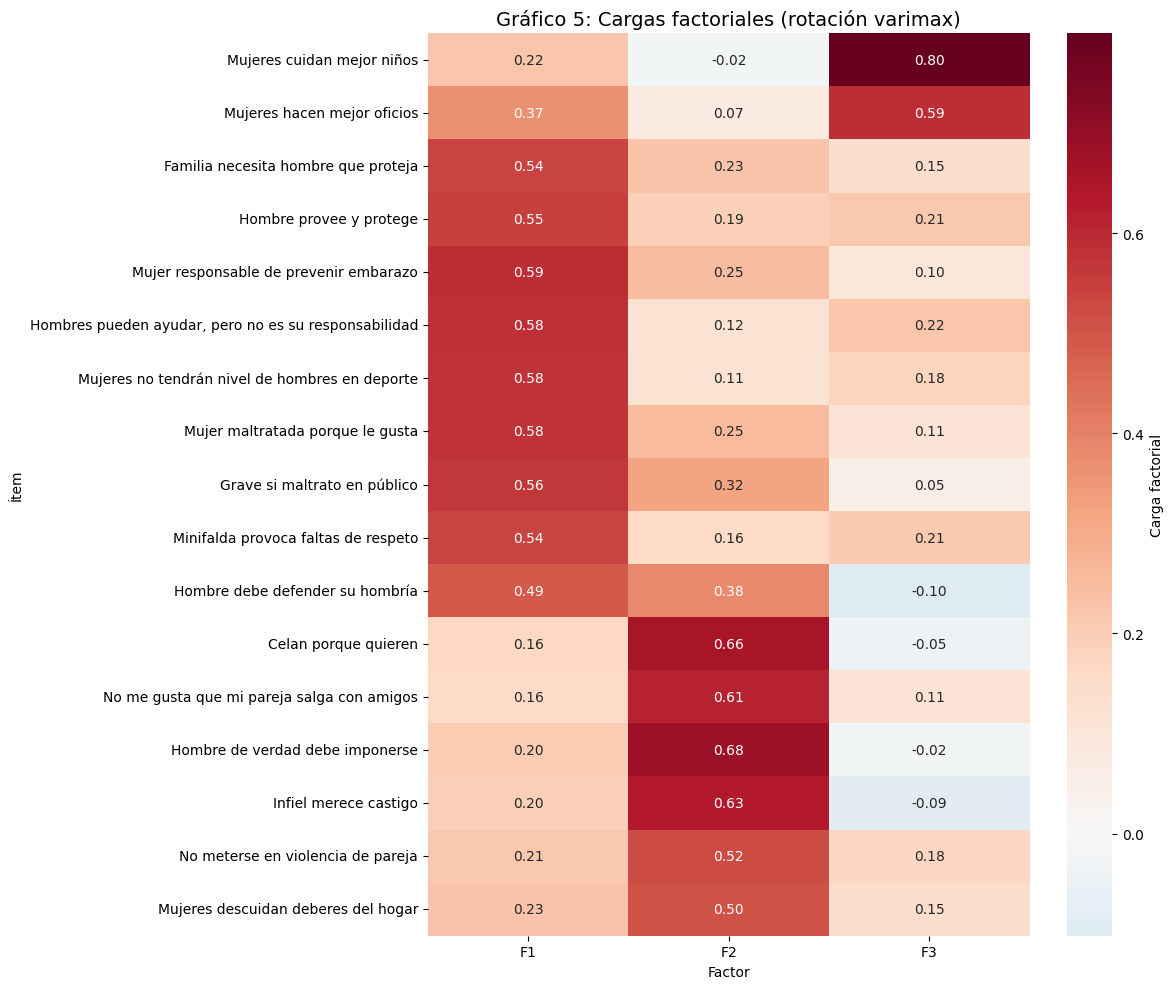

Gráfico 5 guardado en ../../outputs/tableau/grafico5_mapa_calor_factores.png


In [27]:
# ---------- 4. Gráfico 5: Mapa de calor de cargas factoriales ----------
# Usar las cargas ya calculadas en el Paso 4.4 (fa_3.loadings_)
# Renombrar ítems con etiquetas abreviadas para el mapa
item_labels_breves = {
    "P10.1": "Mujeres cuidan mejor niños",
    "P10.2": "Mujeres hacen mejor oficios",
    "P10.3": "Familia necesita hombre que proteja",
    "P10.4": "Hombre provee y protege",
    "P10.5": "Mujer responsable de prevenir embarazo",
    "P10.6": "Hombres pueden ayudar, pero no es su responsabilidad",
    "P10.7": "Mujeres no tendrán nivel de hombres en deporte",
    "P10.8": "Mujer maltratada porque le gusta",
    "P10.9": "Grave si maltrato en público",
    "P10.10": "Minifalda provoca faltas de respeto",
    "P10.11": "Hombre debe defender su hombría",
    "P12.1": "Celan porque quieren",
    "P12.2": "No me gusta que mi pareja salga con amigos",
    "P12.3": "Hombre de verdad debe imponerse",
    "P12.4": "Infiel merece castigo",
    "P12.5": "No meterse en violencia de pareja",
    "P12.6": "Mujeres descuidan deberes del hogar"
}

# Cargas ya en cargas_df (del Paso 4.4)
cargas_heatmap = cargas[["F1", "F2", "F3"]].copy()
cargas_heatmap.index = cargas_heatmap.index.map(lambda x: item_labels_breves.get(x, x))

plt.figure(figsize=(12, 10))
sns.heatmap(cargas_heatmap, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Carga factorial"})
plt.title("Gráfico 5: Cargas factoriales (rotación varimax)", fontsize=14)
plt.ylabel("Ítem")
plt.xlabel("Factor")
plt.tight_layout()
ruta_grafico5 = "../../outputs/tableau/grafico5_mapa_calor_factores.png"
plt.savefig(ruta_grafico5, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gráfico 5 guardado en {ruta_grafico5}")

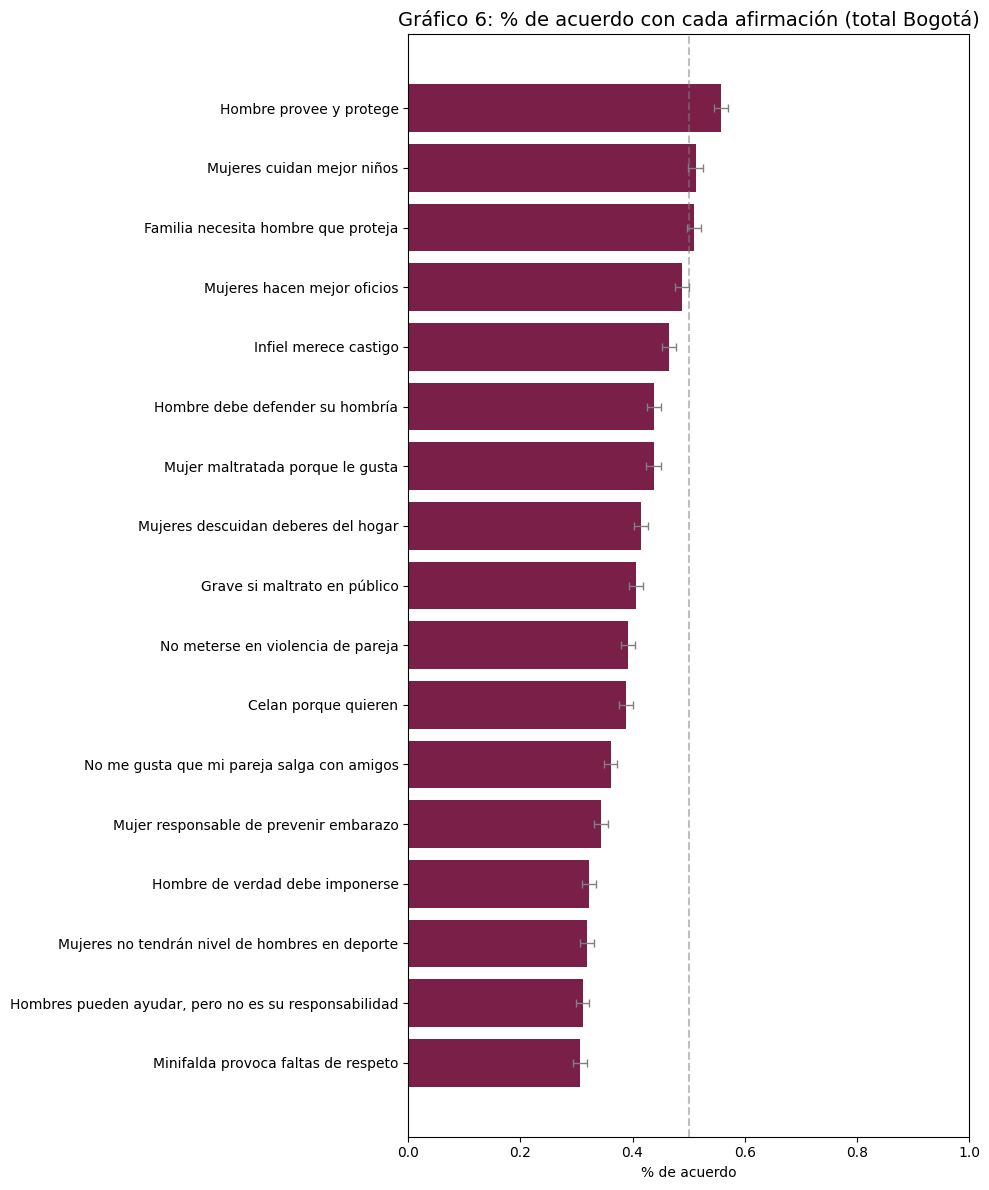

Gráfico 6 guardado en ../../outputs/tableau/grafico6_porcentaje_acuerdo.png


In [29]:
# ---------- 5. Gráfico 6: % de acuerdo por ítem (total Bogotá) con IC ----------
# Calcular proporción de "De acuerdo" (código 2) para cada ítem
# Usar todos los datos de df_bienal (sin pesos, porque no tenemos pesos para la Bienal)
# Si se quiere IC, se puede usar bootstrap simple sobre individuos
items = ITEMS_TOTAL
props = {}
for item in items:
    data = df_bienal[item].dropna()
    n = len(data)
    p = (data == 2).mean()
    # IC 95% usando aproximación normal (Wald) para proporción
    se = np.sqrt(p * (1 - p) / n)
    ci_low = max(0, p - 1.96 * se)
    ci_high = min(1, p + 1.96 * se)
    props[item] = {"prop": p, "ci_low": ci_low, "ci_high": ci_high, "n": n}

prop_df = pd.DataFrame(props).T
prop_df["item_abrev"] = prop_df.index.map(lambda x: item_labels_breves.get(x, x))
prop_df = prop_df.sort_values("prop", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(prop_df["item_abrev"], prop_df["prop"], color="#7a2048",
         xerr=(prop_df["prop"] - prop_df["ci_low"], prop_df["ci_high"] - prop_df["prop"]),
         capsize=3, error_kw={"ecolor": "gray", "linewidth": 1})
plt.xlabel("% de acuerdo")
plt.title("Gráfico 6: % de acuerdo con cada afirmación (total Bogotá)", fontsize=14)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.xlim(0, 1)
plt.tight_layout()
ruta_grafico6 = "../../outputs/tableau/grafico6_porcentaje_acuerdo.png"
plt.savefig(ruta_grafico6, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gráfico 6 guardado en {ruta_grafico6}")


In [30]:
texto_supuesto_4_6 = f"""
## Paso 4.6. Agregar por localidad ponderando por `FACTOR`, con IC 95%. (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

### 1. Fuente de datos y diseño muestral

- **Dataset:** `dataset_encuestaBienal_limpio.csv` (n = 5.860 individuos).
- **Factor de expansión:** `FACTOR` (encontrado en el dataset y utilizado para todas las agregaciones territoriales).
- **Registros utilizados en la agregación:** 5.381 (excluye aquellos sin `codigo_localidad` o sin factor de expansión válido).
- **Unidades territoriales:** 19 localidades (Sumapaz no está presente en la encuesta Bienal).
- **Conglomerado para bootstrap:** `codigo_UPL` (891 UPLs únicos en la Bienal).

### 2. Agregación de puntajes factoriales por localidad

Se calcularon los promedios ponderados de los tres puntajes factoriales estandarizados (`F1_z`, `F2_z`, `F3_z`) para cada localidad, utilizando `FACTOR` como ponderador poblacional.

**Promedios factoriales por localidad (n=5.381):**

| codigo_localidad | nombre_oficial | F1_z | F2_z | F3_z | n |
|---|---|---|---|---|---|
| 1 | Usaquén | 0.084 | 0.391 | -0.498 | 295 |
| 2 | Chapinero | -0.101 | -0.296 | 0.242 | 223 |
| 3 | Santa Fe | 0.204 | 0.030 | 0.207 | 174 |
| 4 | San Cristóbal | -0.128 | -0.031 | 0.209 | 207 |
| 5 | Usme | 0.026 | -0.128 | -0.085 | 346 |
| 6 | Tunjuelito | 0.091 | 0.293 | -0.341 | 275 |
| 7 | Bosa | -0.220 | 0.238 | -0.032 | 319 |
| 8 | Kennedy | 0.217 | -0.069 | 0.170 | 345 |
| 9 | Fontibón | -0.054 | 0.096 | -0.277 | 327 |
| 10 | Engativá | 0.077 | -0.122 | 0.193 | 519 |
| 11 | Suba | -0.155 | -0.499 | 0.184 | 376 |
| 12 | Barrios Unidos | -0.199 | -0.329 | 0.056 | 221 |
| 13 | Teusaquillo | 0.204 | -0.102 | 0.135 | 235 |
| 14 | Los Mártires | 0.275 | 0.311 | -0.242 | 208 |
| 15 | Antonio Nariño | 0.193 | 0.050 | 0.075 | 221 |
| 16 | Puente Aranda | 0.136 | -0.044 | 0.217 | 219 |
| 17 | La Candelaria | 0.194 | 0.528 | -0.412 | 130 |
| 18 | Rafael Uribe Uribe | 0.038 | 0.005 | 0.291 | 287 |
| 19 | Ciudad Bolívar | -0.196 | -0.055 | -0.289 | 454 |

**Interpretación de los extremos:**
- **F1_z (dimensión general de actitudes de género):** mayor en **Los Mártires** (0.275), **Kennedy** (0.217) y **Santa Fe** (0.204); menor en **Bosa** (-0.220), **Barrios Unidos** (-0.199) y **Ciudad Bolívar** (-0.196).
- **F2_z (control en la pareja):** mayor en **La Candelaria** (0.528) y **Usaquén** (0.391); menor en **Suba** (-0.499) y **Barrios Unidos** (-0.329).
- **F3_z (esencialismo específico):** mayor en **Rafael Uribe** (0.291) y **Chapinero** (0.242); menor en **Usaquén** (-0.498) y **La Candelaria** (-0.412).

### 3. Intervalos de confianza al 95% por bootstrap

Se calcularon intervalos de confianza para `F1_z` mediante bootstrap por conglomerado (remuestreo de UPLs con reemplazo, 500 réplicas, 13.36 segundos de cómputo). Este método respeta la estructura de conglomerados del diseño muestral y no requiere supuestos de normalidad.

**Resultados bootstrap para F1_z (IC 95%):**

| codigo_localidad | factor | ci_lower | ci_upper |
|---|---|---|---|
| 1 | F1_z | -0.063 | 0.263 |
| 2 | F1_z | -0.252 | 0.104 |
| 3 | F1_z | -0.121 | 0.577 |
| 4 | F1_z | -0.310 | 0.083 |
| 5 | F1_z | -0.130 | 0.166 |
| 6 | F1_z | -0.067 | 0.254 |
| 7 | F1_z | -0.387 | -0.057 |
| 8 | F1_z | -0.041 | 0.469 |
| 9 | F1_z | -0.183 | 0.071 |
| 10 | F1_z | -0.049 | 0.192 |
| 11 | F1_z | -0.252 | -0.059 |
| 12 | F1_z | -0.346 | -0.099 |
| 13 | F1_z | 0.045 | 0.411 |
| 14 | F1_z | 0.048 | 0.521 |
| 15 | F1_z | -0.087 | 0.522 |
| 16 | F1_z | -0.003 | 0.297 |
| 17 | F1_z | -0.113 | 0.469 |
| 18 | F1_z | -0.112 | 0.175 |
| 19 | F1_z | -0.326 | -0.067 |

**Observaciones sobre la precisión:**
- Las localidades con mayor precisión (IC más estrecho) son aquellas con mayor n muestral: **Engativá** (n=519), **Ciudad Bolívar** (n=454), **Suba** (n=376), **Kennedy** (n=345) e **Usme** (n=346).
- Las localidades con menor precisión (IC más amplio), donde la estimación puntual debe leerse con mayor cautela, son **La Candelaria** (n=130, IC [-0.113, 0.469]), **Antonio Nariño** (n=221, IC [-0.087, 0.522]), **Los Mártires** (n=208, IC [0.048, 0.521]) y **Santa Fe** (n=174, IC [-0.121, 0.577]). Este patrón coincide con el diagnóstico del Gráfico de Control 1 (Paso 1.7) y se replicará la nota de precaución para estas localidades en el dashboard.

### 4. Tabla territorial final (incluyendo ICs)

| codigo_localidad | nombre_oficial | F1_z | F2_z | F3_z | n | F1_z_ci_lower | F1_z_ci_upper |
|---|---|---|---|---|---|---|---|
| 1 | Usaquén | 0.084 | 0.391 | -0.498 | 295 | -0.063 | 0.263 |
| 2 | Chapinero | -0.101 | -0.296 | 0.242 | 223 | -0.252 | 0.104 |
| 3 | Santa Fe | 0.204 | 0.030 | 0.207 | 174 | -0.121 | 0.577 |
| 4 | San Cristóbal | -0.128 | -0.031 | 0.209 | 207 | -0.310 | 0.083 |
| 5 | Usme | 0.026 | -0.128 | -0.085 | 346 | -0.130 | 0.166 |
| 6 | Tunjuelito | 0.091 | 0.293 | -0.341 | 275 | -0.067 | 0.254 |
| 7 | Bosa | -0.220 | 0.238 | -0.032 | 319 | -0.387 | -0.057 |
| 8 | Kennedy | 0.217 | -0.069 | 0.170 | 345 | -0.041 | 0.469 |
| 9 | Fontibón | -0.054 | 0.096 | -0.277 | 327 | -0.183 | 0.071 |
| 10 | Engativá | 0.077 | -0.122 | 0.193 | 519 | -0.049 | 0.192 |
| 11 | Suba | -0.155 | -0.499 | 0.184 | 376 | -0.252 | -0.059 |
| 12 | Barrios Unidos | -0.199 | -0.329 | 0.056 | 221 | -0.346 | -0.099 |
| 13 | Teusaquillo | 0.204 | -0.102 | 0.135 | 235 | 0.045 | 0.411 |
| 14 | Los Mártires | 0.275 | 0.311 | -0.242 | 208 | 0.048 | 0.521 |
| 15 | Antonio Nariño | 0.193 | 0.050 | 0.075 | 221 | -0.087 | 0.522 |
| 16 | Puente Aranda | 0.136 | -0.044 | 0.217 | 219 | -0.003 | 0.297 |
| 17 | La Candelaria | 0.194 | 0.528 | -0.412 | 130 | -0.113 | 0.469 |
| 18 | Rafael Uribe Uribe | 0.038 | 0.005 | 0.291 | 287 | -0.112 | 0.175 |
| 19 | Ciudad Bolívar | -0.196 | -0.055 | -0.289 | 454 | -0.326 | -0.067 |

**Archivo exportado:** `outputs/factores_territoriales_bienal.csv`

### 5. Gráficos generados para el dashboard

**Gráfico 5 — Mapa de calor de cargas factoriales**
- **Archivo:** `outputs/tableau/grafico5_mapa_calor_factores.png`
- **Descripción:** mapa de calor con las cargas factoriales de los 17 ítems en los 3 factores (rotación varimax). Los ítems se etiquetaron con su enunciado abreviado para facilitar la lectura.
- **Hallazgo principal:** la visualización confirma que los ítems de no-injerencia (P10.9, P12.5, P12.3, P10.11) no se agrupan en un factor propio; se distribuyen según el bloque del cuestionario (P10 vs. P12). Esto refuerza la conclusión del Paso 4.4: la estructura factorial sigue el formato del cuestionario, no la distinción teórica de contenido.

**Gráfico 6 — Porcentaje de acuerdo por ítem (total Bogotá)**
- **Archivo:** `outputs/tableau/grafico6_porcentaje_acuerdo.png`
- **Descripción:** barras horizontales del % de personas que respondieron "De acuerdo" (código 2) para cada uno de los 17 ítems, ordenadas de mayor a menor. Incluye intervalos de confianza al 95% (aproximación normal).
- **Hallazgo principal:** el ítem P12.5 ("Cuando hay violencia en una relación de pareja, uno no tiene porqué meterse") tiene un porcentaje de acuerdo del ~39.1%, sustancialmente más bajo que la mayoría de los ítems de roles tradicionales (e.g., P10.4 "El rol de todo hombre es proteger y proveer" con ~55.7%). Esto apoya la noción de que la norma de no-injerencia es distinta en su nivel de adhesión social, aunque el análisis factorial no logró aislarla como una dimensión factorial propia.

### 6. Cierre del Paso 4.6

La agregación territorial de los factores de la Bienal está completa y validada con bootstrap por conglomerado. Los gráficos 5 y 6 están listos para incorporarse al dashboard de Tableau. La tabla `factores_territoriales_bienal.csv` servirá como insumo para las fases posteriores (cálculo del INA, correlaciones territoriales para H1′, etc.).

"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_4_5)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md
